# Stats Cheat Sheet — Chapters 1–5
### Descriptive Statistics, Probability & Distributions, Sampling Distributions & CLT, Estimation, Significance Testing

Reference tables + runnable examples for `scipy.stats` / `numpy` / `statsmodels` workflows.

## Chapter 1 — Descriptive Statistics & Data Exploration

| Concept | Function | What it does | Example |
|---|---|---|---|
| Mean | `np.mean(x)` / `df.mean()` | Center of the data | `np.mean(data)` |
| Median | `np.median(x)` | Middle value, robust to outliers | `np.median(data)` |
| Mode | `stats.mode(x)` | Most frequent value | `stats.mode(data)` |
| Std dev / Variance | `np.std(x, ddof=1)` / `np.var(x, ddof=1)` | Spread (use `ddof=1` for sample stats) | `np.std(data, ddof=1)` |
| Range / IQR | `np.ptp(x)`, `np.percentile(x, [25,75])` | Spread via extremes/quartiles | `np.percentile(data, [25,75])` |
| Z-scores | `stats.zscore(x)` | Standardize values | `stats.zscore(data)` |
| Correlation | `np.corrcoef(x, y)` / `stats.pearsonr(x, y)` | Linear association between two variables | `stats.pearsonr(x, y)` |
| Summary stats | `df.describe()` | Quick n/mean/std/min/max/quartiles | `df.describe()` |


In [1]:
import numpy as np
import pandas as pd
from scipy import stats

# Example dataset
data = np.array([5, 7, 3, 9, 5, 6, 8, 5, 4, 10])

print("Mean:", np.mean(data))
print("Median:", np.median(data))
print("Mode:", stats.mode(data, keepdims=True))
print("Sample Std Dev:", np.std(data, ddof=1))
print("Sample Variance:", np.var(data, ddof=1))
print("Range:", np.ptp(data))
print("IQR (Q1, Q3):", np.percentile(data, [25, 75]))
print("Z-scores:", stats.zscore(data))

pd.Series(data).describe()


Mean: 6.2
Median: 5.5
Mode: ModeResult(mode=array([5]), count=array([3]))
Sample Std Dev: 2.250925735484551
Sample Variance: 5.066666666666666
Range: 7
IQR (Q1, Q3): [5.   7.75]
Z-scores: [-0.56195149  0.37463432 -1.4985373   1.31122014 -0.56195149 -0.09365858
  0.84292723 -0.56195149 -1.03024439  1.77951304]


count    10.000000
mean      6.200000
std       2.250926
min       3.000000
25%       5.000000
50%       5.500000
75%       7.750000
max      10.000000
dtype: float64

## Chapter 2 — Probability & Discrete/Continuous Distributions

| Concept | Function | What it does | Example |
|---|---|---|---|
| Exact prob. of one discrete outcome | `<dist>.pmf(k, ...)` | P(X = k) | `binom.pmf(3, 10, 0.5)` |
| Density at a point (continuous) | `<dist>.pdf(x, ...)` | Height of density curve (not a probability itself) | `norm.pdf(0, 5.5, 3.9)` |
| Cumulative probability | `<dist>.cdf(x, ...)` | P(X ≤ x) | `norm.cdf(0, 5.5, 3.9)` |
| Upper-tail probability | `<dist>.sf(x, ...)` | P(X > x), = 1 - cdf | `norm.sf(10, 5.5, 3.9)` |
| Inverse CDF (critical values, percentiles) | `<dist>.ppf(q, ...)` | Find x for a given cumulative prob. | `norm.ppf(0.975)` |
| Simulate random draws | `<dist>.rvs(..., size=n)` | Generate sample data | `binom.rvs(10, 0.5, size=1000)` |
| Binomial (# successes in n trials) | `binom` | Coin flips, yes/no counts | `binom.pmf(k, n, p)` |
| Poisson (rare event counts) | `poisson` | Events per interval | `poisson.pmf(k, mu)` |
| Uniform, continuous | `uniform` | Equally likely over a range | `uniform.pdf(x, loc, scale)` |
| Uniform, discrete | `randint` | Equally likely integers | `randint.pmf(k, low, high)` |
| Geometric (trial # of **first** success) | `geom` | Y = 1, 2, 3, …; P(Y=y) = (1−p)^(y−1)·p; mean 1/p | `geom.pmf(3, 0.5)` |
| Normal | `norm` | Symmetric bell-shaped variable | `norm.cdf(x, mean, sd)` |
| Gamma (skewed, non-negative) | `gamma` | Waiting times, amounts | `gamma.pdf(x, a, scale)` |
| Beta (values in [0,1], e.g. a probability) | `beta` | Prior/posterior for a proportion (Ch.4 Bayes) | `beta.pdf(x, a, b)` |
| Expected value | `E[X] = Σx·p(x)` (manual) | Weighted mean of a distribution | `np.sum(x * p)` |
| Independence / addition rules | manual (no single function) | P(A and B) = P(A)P(B) if independent | — |

In [2]:
from scipy.stats import binom, poisson, uniform, randint, norm, gamma

# Binomial: P(exactly 3 heads in 10 flips)
print("binom.pmf(3,10,0.5):", binom.pmf(3, 10, 0.5))

# Normal: P(X <= 0) for mean=5.5, sd=3.9
print("norm.cdf(0, 5.5, 3.9):", norm.cdf(0, 5.5, 3.9))

# Normal: P(X > 10)
print("norm.sf(10, 5.5, 3.9):", norm.sf(10, 5.5, 3.9))

# Inverse CDF: 97.5th percentile of standard normal (95% CI z-value)
print("norm.ppf(0.975):", norm.ppf(0.975))

# Simulate 1000 binomial draws
sim = binom.rvs(10, 0.5, size=1000)
print("Simulated mean:", sim.mean())

# Expected value from a discrete distribution manually
k = np.arange(0, 11)
p = binom.pmf(k, 10, 0.5)
print("E[X] via weighted sum:", np.sum(k * p))


# Geometric: P(first success on trial 3) with p = 0.5  ->  (0.5)^2 * 0.5 = 0.125
from scipy.stats import geom
print("geom.pmf(3, 0.5):", geom.pmf(3, 0.5))
# NOTE: scipy's geom counts TRIALS (support starts at 1). numpy's rng.geometric does too.

binom.pmf(3,10,0.5): 0.1171875
norm.cdf(0, 5.5, 3.9): 0.07923199226950461
norm.sf(10, 5.5, 3.9): 0.12428162410859106
norm.ppf(0.975): 1.959963984540054
Simulated mean: 5.039
E[X] via weighted sum: 4.999999999999999
geom.pmf(3, 0.5): 0.125


## Chapter 3 — Sampling Distributions & the Central Limit Theorem

| Concept | Function | What it does | Example |
|---|---|---|---|
| Exact sampling distribution of p̂ | `binom.pmf(k, n, p)` then `k/n` | Enumerate all possible sample proportions | see coin-flip problem |
| Simulated sampling distribution | `dist.rvs(..., size=(B, n)).mean(axis=1)` | Monte Carlo approx. of a statistic's distribution | `rng.uniform(0,10,(B,n)).mean(axis=1)` |
| Standard error (formula, proportion) | `np.sqrt(p*(1-p)/n)` | SE of sample proportion | manual |
| Standard error (simulated) | `samples.std(ddof=1)` | SE estimated from simulated sampling dist. | `means.std(ddof=1)` |
| SE of the mean from one sample | `spread / np.sqrt(n)` | Plug-in SE using sample/pop SD | `3.9/np.sqrt(10000)` |
| Informal interval (preview of Ch.4) | `center ± 2*se` (≈95%) or `± 3*se` (≈99.7%) | CLT + empirical rule: ȳ lands within ~2 SE of μ most of the time, so flip it around ȳ | `5.5 ± 3*0.12` |
| Normal approx. to binomial | check `n*p≥10` and `n*(1-p)≥10`, then `norm.cdf` | Approximate binomial with normal when conditions hold | `norm.cdf(x, n*p, sqrt(n*p*(1-p)))` |
| Law of Large Numbers vs. CLT | conceptual, no function | LLN: estimate → true value as n→∞. CLT: shape of sampling dist. → normal as n→∞ | — |
| Bootstrapping | resample your own data | Simulate sampling distribution from observed data (no assumed population param) | `np.random.choice(sample, len(sample), replace=True)` |


> Formal confidence intervals (confidence level, z vs t critical values, proportions, two groups) → **Chapter 4**.

In [3]:
import numpy as np
from numpy.random import default_rng
from scipy.stats import norm

rng = default_rng(42)

# --- Number of good friends example ---
center = 5.5
spread = 3.9
n = 1000

p_below_zero = norm.cdf(0, center, spread)
se = spread / np.sqrt(n)                # SE of the sample mean

# Informal interval: CLT says ybar ~ Normal(mu, se), so ybar is within ~2 SE (95%) / ~3 SE (99.7%) of mu
interval_2se = (center - 2 * se, center + 2 * se)
interval_3se = (center - 3 * se, center + 3 * se)

print("P(Y<0) under normal assumption:", round(p_below_zero, 4))
print("SE:", round(se, 4))
print("~95% interval (±2 SE):", np.round(interval_2se, 3))
print("~99.7% interval (±3 SE):", np.round(interval_3se, 3))
# Formal version with z/t critical values -> Chapter 4

P(Y<0) under normal assumption: 0.0792
SE: 0.1233
~95% interval (±2 SE): [5.253 5.747]
~99.7% interval (±3 SE): [5.13 5.87]


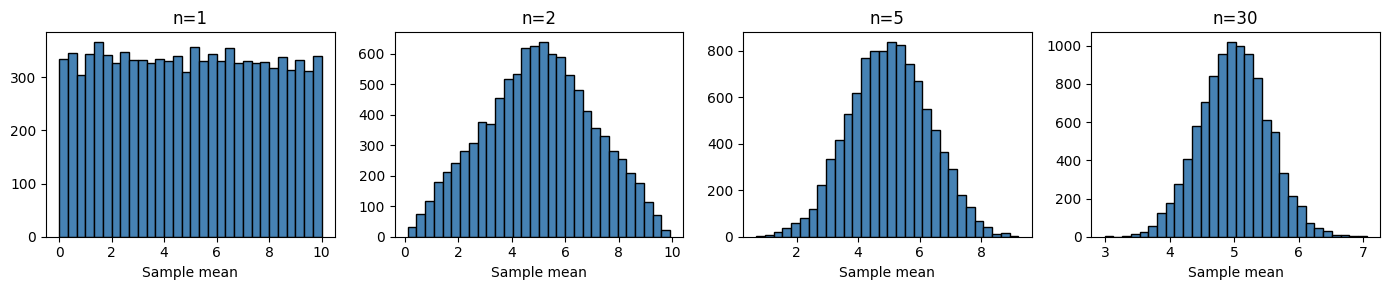

In [4]:
# --- CLT demo: sampling distribution of the mean from a uniform population ---
import matplotlib.pyplot as plt

low, high = 0, 10
B = 10000
n_values = [1, 2, 5, 30]

fig, axes = plt.subplots(1, len(n_values), figsize=(14, 3))
for ax, n_ in zip(axes, n_values):
    x = rng.uniform(low, high, size=(B, n_))
    means = x.mean(axis=1)
    ax.hist(means, bins=30, color="steelblue", edgecolor="black")
    ax.set_title(f"n={n_}")
    ax.set_xlabel("Sample mean")
plt.tight_layout()
plt.show()


## Chapter 4 — Statistical Inference: Estimation

**Core vocabulary**

| Object | Example | Role |
|---|---|---|
| Parameter | μ, π, μ₁ − μ₂ | Fixed, unknown population target |
| Estimator | Ȳ, π̂, Ȳ₁ − Ȳ₂ | Rule applied to sample data (random — varies sample to sample) |
| Estimate | 500, 0.44 | The observed value of the estimator |
| Standard error | s/√n | Estimated spread of the estimator's sampling distribution |
| Interval estimate | estimate ± critical × SE | Range calibrated to a confidence level |

**Estimator quality:** *unbiased* (E[θ̂] = θ), *efficient* (smallest SE among competitors), *consistent* (θ̂ → θ as n → ∞). Compare efficiency by simulation: SE ratio = SE(θ̂₁)/SE(θ̂₂).

| Concept | Function | What it does | Example |
|---|---|---|---|
| Likelihood function | `L(θ \| y) = P(y \| θ)` as a function of θ | How plausible each θ is given the **fixed** observed data | `L = binom.pmf(6, 10, p_grid)` |
| Log-likelihood | `np.log(L)` / `dist.logpmf(...)` | Same maximizer, easier math (products → sums) | `binom.logpmf(6, 10, p)` |
| MLE (grid) | `p_grid[np.argmax(L)]` | θ̂ = arg max L(θ) | see code below |
| MLE (optimizer) | `minimize_scalar(lambda p: -loglik(p), bounds=(0,1), method="bounded")` | Numeric MLE when no closed form | `.x` |
| Known MLEs | closed form | Binomial π̂ = y/n · Geometric p̂ = 1/y (one obs) · Poisson λ̂ = ȳ · Normal μ̂ = ȳ | — |
| Estimator precision by simulation | `rng.normal(size=(B, n))` → stat per row → `.std(ddof=1)` | Empirical SE of any estimator | `np.quantile(x, .25, axis=1)` |
| General CI form | `estimate ± critical value × SE` | Width = precision; confidence level = certainty (higher level → wider) | — |
| z critical value | `norm.ppf(1 - alpha/2)` | Multiplier when σ known (or large-n proportion) | `norm.ppf(0.975)` → 1.96 |
| t critical value | `t.ppf(1 - alpha/2, df=n-1)` | Multiplier when σ estimated by s; heavier tails | `t.ppf(0.975, 10)` → 2.228 |
| CI for mean, σ known | `norm.interval(0.95, loc=xbar, scale=sigma/np.sqrt(n))` | x̄ ± z·σ/√n | z* = 1.96 |
| CI for mean, σ unknown (the usual case) | `t.interval(0.95, df=n-1, loc=xbar, scale=s/np.sqrt(n))` | x̄ ± t*·s/√n | `stats.ttest_1samp(x, 0).confidence_interval()` |
| CI for a proportion (Wilson) | `proportion_confint(k, n, method="wilson")` | Stays inside [0,1]; better than Wald near 0/1 or small n | `proportion_confint(778, 1497, method="wilson")` |
| CI for a proportion (Wald) | `p̂ ± z*·√(p̂(1−p̂)/n)` | Textbook formula; can go below 0 / above 1 | `method="normal"` |
| CI for μ₁ − μ₂ (Welch) | `stats.ttest_ind(a, b, equal_var=False).confidence_interval()` | (x̄₁−x̄₂) ± t*·√(s₁²/n₁ + s₂²/n₂); no equal-variance assumption | SciPy ≥ 1.11 |
| CI for π₁ − π₂ | `(p1-p2) ± z*·√(p1(1-p1)/n1 + p2(1-p2)/n2)` | Unpooled SE for intervals | manual |
| Bootstrap CI | `stats.bootstrap((x,), np.median, n_resamples=10_000, method="BCa")` | CI for any statistic (median, IQR, …) by resampling your data | `.confidence_interval` |
| Bayesian: Beta-binomial update | prior `Beta(a, b)` + y of n → `Beta(a+y, b+n−y)` | Conjugate update: add successes/failures to prior counts | `beta(28, 22)` |
| Credible interval | `beta.interval(0.95, a_post, b_post)` | P(π in interval \| data) = 0.95 (a real probability statement about π) | equal-tail |
| Posterior predictive | `betabinom(m, a_post, b_post).interval(0.95)` | Range for # successes in m **future** trials (wider: adds outcome noise) | `betabinom(20, 28, 22)` |
| Margin of error vs n | MOE ∝ 1/√n | 4× the sample size → half the MOE | — |

**Interpreting a 95% CI (frequentist):** the *procedure* captures μ in ~95% of repeated samples. It is **not** "95% chance μ is in this particular interval" — that phrasing is only valid for a Bayesian *credible* interval.

**z vs t:** σ known → z. σ estimated by s → t with df = n−1 (heavier tails; t* → 1.96 as n grows: df=3 → 3.182, df=10 → 2.228, df=30 → 2.042).

Binomial y=6, n=10: grid MLE = 0.600, max L = 0.2508
Geometric y=3: grid MLE = 0.333, max L = 0.1481
Geometric MLE via optimizer: 0.3333  (closed form 1/y = 0.3333 )


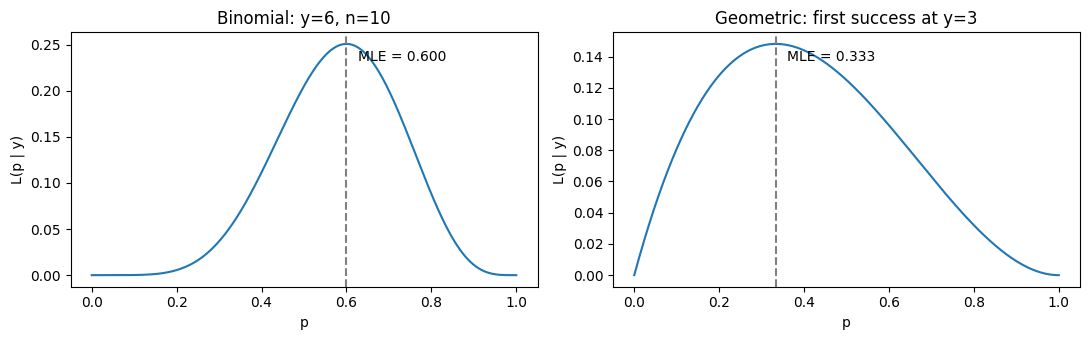

In [5]:
# --- Likelihood & MLE ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, geom
from scipy.optimize import minimize_scalar

p = np.linspace(0, 1, 1001)           # grid of candidate parameter values

# (1) Binomial: y = 6 successes in n = 10 trials  ->  L(p) = C(10,6) p^6 (1-p)^4
L_binom = binom.pmf(6, 10, p)

# (2) Geometric: first success on trial y = 3  ->  2 failures then 1 success
#     L(p | y=3) = (1-p)^(3-1) * p = (1-p)^2 * p
y = 3
L_geom = (1 - p) ** (y - 1) * p       # same as geom.pmf(y, p)
assert np.allclose(L_geom[1:-1], geom.pmf(y, p[1:-1]))  # skip p=0,1 edges (scipy returns nan there)

for name, L in [("Binomial y=6, n=10", L_binom), ("Geometric y=3", L_geom)]:
    print(f"{name}: grid MLE = {p[np.argmax(L)]:.3f}, max L = {L.max():.4f}")

# Numeric MLE via optimizer (minimize the NEGATIVE log-likelihood)
res = minimize_scalar(lambda q: -geom.logpmf(y, q), bounds=(1e-9, 1 - 1e-9), method="bounded")
print("Geometric MLE via optimizer:", round(res.x, 4), " (closed form 1/y =", round(1 / y, 4), ")")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, L, title, mle in [(axes[0], L_binom, "Binomial: y=6, n=10", 0.6),
                          (axes[1], L_geom, "Geometric: first success at y=3", 1 / 3)]:
    ax.plot(p, L)
    ax.axvline(mle, ls="--", color="gray")
    ax.set_title(title)
    ax.set_xlabel("p")
    ax.set_ylabel("L(p | y)")
    ax.annotate(f"MLE = {mle:.3f}", (mle, L.max()), textcoords="offset points", xytext=(8, -12))
plt.tight_layout()
plt.show()
# Reminder: likelihood compares p values for FIXED data. It is not a pdf over p (area != 1).

In [6]:
# --- Estimator precision by simulation (compare two estimators of mu) ---
rng = np.random.default_rng(42)
B, n = 100_000, 100
X = rng.normal(0, 1, size=(B, n))

mean_est = X.mean(axis=1)
midhinge = (np.quantile(X, 0.25, axis=1) + np.quantile(X, 0.75, axis=1)) / 2

print("SE(mean)     simulated:", mean_est.std(ddof=1).round(4), "| theory 1/sqrt(n) =", 1 / np.sqrt(n))
print("SE(midhinge) simulated:", midhinge.std(ddof=1).round(4))
print("Efficiency ratio SE(midhinge)/SE(mean):", (midhinge.std(ddof=1) / mean_est.std(ddof=1)).round(3))

SE(mean)     simulated: 0.1003 | theory 1/sqrt(n) = 0.1
SE(midhinge) simulated: 0.1107
Efficiency ratio SE(midhinge)/SE(mean): 1.104


In [7]:
# --- Confidence intervals ---
from scipy import stats
from scipy.stats import norm, t
from statsmodels.stats.proportion import proportion_confint

# (a) Mean, sigma unknown -> t interval, from SUMMARY stats (kiosk example: xbar=500, s=5, n=11)
xbar, s, n = 500, 5, 11
se = s / np.sqrt(n)
t_star = t.ppf(0.975, df=n - 1)
print("t* =", round(t_star, 3), "| manual t CI:", (round(xbar - t_star * se, 2), round(xbar + t_star * se, 2)))
print("t.interval:", t.interval(0.95, df=n - 1, loc=xbar, scale=se))

# (b) Mean from RAW data -> let scipy do it
x = np.array([0, 0, 1, 1, 1, 2, 2, 3, 4, 5])
print("ttest_1samp CI:", stats.ttest_1samp(x, popmean=0).confidence_interval(0.95))

# (c) Proportion: Wilson (preferred) vs Wald
print("Wilson 778/1497:", proportion_confint(778, 1497, method="wilson"))
ph = 1 / 20
wald = (ph - 1.96 * np.sqrt(ph * (1 - ph) / 20), ph + 1.96 * np.sqrt(ph * (1 - ph) / 20))
print("Wald   1/20     :", np.round(wald, 3), " <- negative lower bound! (statsmodels method='normal' silently clips it to 0)")
print("Wilson 1/20     :", proportion_confint(1, 20, method="wilson"))

# (d) Difference of two means (Welch)
a = rng.normal(10, 2, 40)
b = rng.normal(9, 3, 35)
welch = stats.ttest_ind(a, b, equal_var=False)
print("Welch diff:", round(a.mean() - b.mean(), 3), "| 95% CI:", welch.confidence_interval(0.95))

# (e) Difference of two proportions (unpooled Wald)
x1, n1, x2, n2 = 1017, 1178, 703, 945
p1, p2 = x1 / n1, x2 / n2
se_d = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)
z = norm.ppf(0.975)
print("p1 - p2 =", round(p1 - p2, 4), "| 95% CI:", (round(p1 - p2 - z * se_d, 4), round(p1 - p2 + z * se_d, 4)))

t* = 2.228 | manual t CI: (np.float64(496.64), np.float64(503.36))
t.interval: (np.float64(496.6409542941583), np.float64(503.3590457058417))
ttest_1samp CI: ConfidenceInterval(low=np.float64(0.7101254023728163), high=np.float64(3.0898745976271833))
Wilson 778/1497: (0.4943793119474541, 0.5449319688365669)
Wald   1/20     : [-0.046  0.146]  <- negative lower bound! (statsmodels method='normal' silently clips it to 0)
Wilson 1/20     : (0.008881448800795402, 0.2361311934467421)
Welch diff: 0.9 | 95% CI: ConfidenceInterval(low=np.float64(-0.3646554368384385), high=np.float64(2.163862781534986))
p1 - p2 = 0.1194 | 95% CI: (np.float64(0.0854), np.float64(0.1535))


In [8]:
# --- Bootstrap CI (for statistics with no easy SE formula, e.g. the median) ---
from scipy.stats import bootstrap

data = rng.gamma(2, 3, size=60)                 # skewed sample
res = bootstrap((data,), np.median, n_resamples=10_000, method="BCa", rng=rng)
print("Sample median:", np.median(data).round(3))
print("95% BCa bootstrap CI:", res.confidence_interval)
print("Bootstrap SE:", res.standard_error.round(3))
# method="percentile" also exists; BCa corrects for bias/skew.
# (SciPy < 1.15 uses random_state=rng instead of rng=rng)

Sample median: 4.908
95% BCa bootstrap CI: ConfidenceInterval(low=np.float64(4.059752645031499), high=np.float64(6.217206671517207))
Bootstrap SE: 0.577


Posterior: Beta(28, 22), mean = 0.560
95% credible interval: [0.422 0.693]
P(pi > 0.5 | data): 0.804
95% predictive interval for future successes (of 20): (np.float64(6.0), np.float64(16.0))


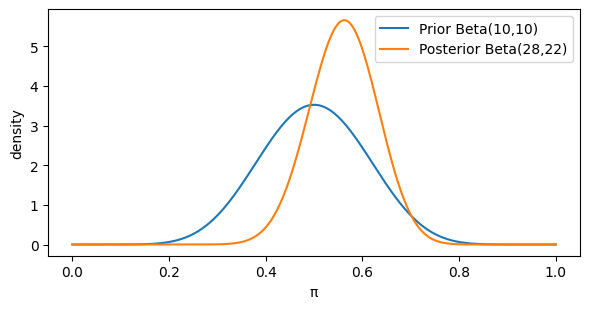

In [9]:
# --- Bayesian estimation: Beta prior + Binomial data -> Beta posterior ---
from scipy.stats import beta, betabinom

a_prior, b_prior = 10, 10          # prior centered at 0.5
y, n = 18, 30                      # data: 18 successes in 30 trials
a_post, b_post = a_prior + y, b_prior + (n - y)   # Beta(28, 22)

post = beta(a_post, b_post)
print(f"Posterior: Beta({a_post}, {b_post}), mean = {post.mean():.3f}")
print("95% credible interval:", np.round(post.interval(0.95), 3))
print("P(pi > 0.5 | data):", round(post.sf(0.5), 3))

# Posterior predictive: successes in m = 20 future trials
pred = betabinom(20, a_post, b_post)
print("95% predictive interval for future successes (of 20):", pred.interval(0.95))

grid = np.linspace(0, 1, 500)
plt.figure(figsize=(6, 3.2))
plt.plot(grid, beta.pdf(grid, a_prior, b_prior), label="Prior Beta(10,10)")
plt.plot(grid, post.pdf(grid), label=f"Posterior Beta({a_post},{b_post})")
plt.xlabel("π"); plt.ylabel("density"); plt.legend(); plt.tight_layout(); plt.show()

## Chapter 5 — Statistical Inference: Significance Tests

**Five steps:** (1) Assumptions — data type, randomization, sample size, distribution · (2) Hypotheses — H₀ (no effect, a single value) vs Hₐ (two-sided `≠`, or one-sided `>` / `<` chosen **before** seeing data) · (3) Test statistic — usually (estimate − H₀ value) / SE₀ · (4) P-value — P(statistic at least this extreme | H₀ true) · (5) Conclusion — in context; "reject H₀" or "fail to reject H₀" (never "accept H₀").

**Test statistic → reference distribution**

| Situation | Statistic | Reference | Python |
|---|---|---|---|
| One proportion, large n | z = (π̂ − π₀) / √(π₀(1−π₀)/n) — SE uses **π₀** | N(0,1) | `proportions_ztest(k, n, value=π0, prop_var=π0)` |
| One proportion, small n (exact) | y ~ Binomial(n, π₀) | Binomial | `stats.binomtest(k, n, p=π0, alternative="greater")` |
| One mean | t = (ȳ − μ₀) / (s/√n) | t, df = n−1 | `stats.ttest_1samp(x, popmean=μ0)` |
| Paired / matched data (before-after, same subjects) | one-sample t on the differences | t, df = n−1 | `stats.ttest_rel(a, b)` |
| Two independent means | t = (ȳ₁−ȳ₂) / √(s₁²/n₁ + s₂²/n₂) | t (Welch df) | `stats.ttest_ind(a, b, equal_var=False)` |
| Two means, equal-variance ("pooled") | pooled s | t, df = n₁+n₂−2 | `stats.ttest_ind(a, b, equal_var=True)` |
| Two proportions | z = (π̂₁−π̂₂) / √(π̂(1−π̂)(1/n₁+1/n₂)) — **pooled** π̂ | N(0,1) | `proportions_ztest([x1, x2], [n1, n2])` |
| Independence of two categorical variables | χ² = Σ (O−E)²/E, E = row total·col total / N | χ², df = (r−1)(c−1) | `stats.chi2_contingency(table, correction=False)` |
| 2×2 table with small counts | exact | hypergeometric | `stats.fisher_exact(table)` |
| Two groups, no normality (ranks) | Wilcoxon rank-sum / Mann-Whitney | exact or normal approx | `stats.mannwhitneyu(a, b)` |
| Any statistic, minimal assumptions | shuffle group labels | permutation distribution | `stats.permutation_test(...)` |

**Reading the result**

| Concept | Meaning | Python / formula |
|---|---|---|
| P-value from z | two-sided: 2·P(Z ≥ \|z\|) · one-sided `>`: P(Z ≥ z) | `2 * norm.sf(abs(z))` / `norm.sf(z)` |
| P-value from t | same idea with t | `2 * t.sf(abs(tstat), df)` |
| Significance level α | Reject H₀ if P ≤ α (commonly 0.05) | fixed **before** analysis |
| Test ↔ CI duality | Two-sided test at α rejects H₀: μ = μ₀ ⇔ μ₀ is outside the (1−α) CI | `res.confidence_interval(1-α)` |
| Type I error | Reject H₀ when it's true; P = α | — |
| Type II error | Fail to reject H₀ when it's false; P = β | — |
| Power | 1 − β = P(reject H₀ \| Hₐ true). ↑ with larger n, bigger effect, less noise, larger α | `TTestIndPower().solve_power(...)` |
| Effect size | Cohen's d = (ȳ₁−ȳ₂)/s_pooled · Cramér's V for χ² | `stats.contingency.association(table)` |
| Standardized residuals (χ²) | (O−E)/SE; \|r\| > 2–3 marks cells driving the association | `sm.stats.Table(t).standardized_resids` |
| Multiple testing | Many tests → false positives. Bonferroni: use α/m. FDR (Benjamini-Hochberg) is less strict | `multipletests(pvals, method="fdr_bh")` |
| Bayesian analog of a one-sided P-value | posterior P(π ≤ π₀ \| data) with Beta(a+y, b+n−y) | `beta.cdf(π0, a+y, b+n-y)` |
| Likelihood-ratio test | 2·(log L_max − log L₀) ~ χ² with df = # restricted params | `chi2.sf(2*(ll1-ll0), df)` |

**Common traps:** P-value ≠ P(H₀ true). Statistical significance ≠ practical importance (huge n makes tiny effects "significant"). Failing to reject ≠ proving H₀. Paired data analyzed as independent loses power (wrong test). χ² needs expected counts ≳ 5; otherwise use Fisher/exact.

In [10]:
# --- One proportion: z test vs exact binomial ---
import numpy as np
from scipy import stats
from scipy.stats import norm, t, beta, chi2
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

k, n, pi0 = 524, 1008, 0.50          # climate-change poll example
p_hat = k / n
z = (p_hat - pi0) / np.sqrt(pi0 * (1 - pi0) / n)          # SE under H0 uses pi0
print(f"p_hat = {p_hat:.4f}, z = {z:.4f}, two-sided P = {2 * norm.sf(abs(z)):.4f}")

z_sm, p_sm = proportions_ztest(k, n, value=pi0, prop_var=pi0)   # prop_var=pi0 -> textbook null SE
print(f"statsmodels: z = {z_sm:.4f}, P = {p_sm:.4f}")
# (without prop_var, statsmodels uses p_hat in the SE -> slightly different z)

exact = stats.binomtest(k, n, p=pi0, alternative="two-sided")
print(f"Exact binomial P = {exact.pvalue:.4f}")
print("Report with a CI:", np.round(proportion_confint(k, n, method="wilson"), 4))

# One-sided Ha: pi > 0.5
print("One-sided exact P (greater):", round(stats.binomtest(k, n, p=pi0, alternative="greater").pvalue, 4))

p_hat = 0.5198, z = 1.2599, two-sided P = 0.2077
statsmodels: z = 1.2599, P = 0.2077
Exact binomial P = 0.2193
Report with a CI: [0.489  0.5505]
One-sided exact P (greater): 0.1096


In [11]:
# --- Bayesian counterpart: posterior P(pi <= 0.5) plays the role of a one-sided P-value ---
a, b = 1, 1                                   # uniform prior (try a "strong" prior like Beta(50,50) to compare)
for a0, b0 in [(1, 1), (50, 50)]:
    post_lt = beta.cdf(0.5, a0 + k, b0 + n - k)
    print(f"Prior Beta({a0},{b0}): P(pi <= 0.5 | data) = {post_lt:.4f}")
# A strong prior centered at 0.5 pulls the posterior toward 0.5 -> weaker evidence, especially for small n.

Prior Beta(1,1): P(pi <= 0.5 | data) = 0.1040
Prior Beta(50,50): P(pi <= 0.5 | data) = 0.1146


In [12]:
# --- Means: one-sample, paired, two independent groups ---
rng = np.random.default_rng(500)

# One-sample t: H0: mu = 4.0
x = rng.normal(3.6, 1.5, 60)
one = stats.ttest_1samp(x, popmean=4.0)
print(f"One-sample: t = {one.statistic:.3f}, df = {one.df}, P = {one.pvalue:.4f}, 95% CI = {np.round(one.confidence_interval(0.95), 3)}")
# Duality: P < 0.05  <=>  4.0 is outside the 95% CI

# Paired t: same 8 students, phone vs control reaction time (ms)
phone   = np.array([636, 623, 615, 672, 601, 600, 542, 554])
control = np.array([604, 556, 540, 522, 459, 544, 513, 470])
paired = stats.ttest_rel(phone, control)
print(f"Paired: mean diff = {(phone - control).mean():.1f}, t = {paired.statistic:.3f}, P = {paired.pvalue:.5f}")
print("   same as ttest_1samp on differences:", round(stats.ttest_1samp(phone - control, 0).pvalue, 5))
print("   WRONG (treated as independent) Welch P:", round(stats.ttest_ind(phone, control, equal_var=False).pvalue, 5))

# Two independent groups: Welch (default choice)
g1 = rng.normal(22.3, 6.9, 43)
g2 = rng.normal(25.9, 8.0, 50)
welch = stats.ttest_ind(g2, g1, equal_var=False)
sp = np.sqrt(((len(g1) - 1) * g1.var(ddof=1) + (len(g2) - 1) * g2.var(ddof=1)) / (len(g1) + len(g2) - 2))
d = (g2.mean() - g1.mean()) / sp
print(f"Welch: t = {welch.statistic:.3f}, df = {welch.df:.1f}, P = {welch.pvalue:.4f}, "
      f"95% CI = {np.round(welch.confidence_interval(0.95), 2)}, Cohen's d = {d:.2f}")

# Nonparametric alternative (no normality assumption)
print("Mann-Whitney P:", round(stats.mannwhitneyu(g2, g1, alternative="two-sided").pvalue, 4))

One-sample: t = -2.595, df = 59, P = 0.0119, 95% CI = [3.042 3.876]
Paired: mean diff = 79.4, t = 4.944, P = 0.00167
   same as ttest_1samp on differences: 0.00167
   WRONG (treated as independent) Welch P: 0.00317
Welch: t = 3.462, df = 88.2, P = 0.0008, 95% CI = [2.38 8.79], Cohen's d = 0.70


Mann-Whitney P: 0.0013


In [13]:
# --- Two proportions ---
x1, n1, x2, n2 = 1017, 1178, 703, 945
z2, p2 = proportions_ztest([x1, x2], [n1, n2])        # pooled SE under H0: pi1 = pi2
print(f"Two-proportion z = {z2:.3f}, P = {p2:.3g}")

Two-proportion z = 6.973, P = 3.11e-12


In [14]:
# --- Chi-square test of independence (categorical x categorical) ---
import pandas as pd
import statsmodels.api as sm

# Build a table from raw data with pd.crosstab(df["row_var"], df["col_var"])
table = pd.DataFrame([[45, 30, 12], [28, 40, 25], [4, 2, 9]],
                     index=["Undergrad", "Grad", "PhD"], columns=["Low", "Medium", "High"])   # made-up counts
print(table, "\n")

res = stats.chi2_contingency(table, correction=False)
print(f"chi2 = {res.statistic:.3f}, df = {res.dof}, P = {res.pvalue:.4f}")
print("Expected counts:\n", pd.DataFrame(res.expected_freq, index=table.index, columns=table.columns).round(2))
print("Min expected count:", res.expected_freq.min().round(2), "-> flag if < 5 (approximation may be poor)")

print("\nStandardized residuals:\n", sm.stats.Table(table).standardized_resids.round(2))
print("Cramér's V:", round(stats.contingency.association(table, method="cramer"), 3))

# Small 2x2 table -> Fisher's exact test
print("Fisher exact (2x2) P:", round(stats.fisher_exact([[3, 7], [9, 2]]).pvalue, 4))

           Low  Medium  High
Undergrad   45      30    12
Grad        28      40    25
PhD          4       2     9 

chi2 = 21.727, df = 4, P = 0.0002
Expected counts:
              Low  Medium   High
Undergrad  34.35   32.12  20.52
Grad       36.72   34.34  21.94
PhD         5.92    5.54   3.54
Min expected count: 3.54 -> flag if < 5 (approximation may be poor)

Standardized residuals:
             Low  Medium  High
Undergrad  3.14   -0.63 -2.89
Grad      -2.56    1.68  1.03
PhD       -1.06   -1.97  3.46
Cramér's V: 0.236
Fisher exact (2x2) P: 0.03


In [15]:
# --- Power, sample size, multiple testing, likelihood-ratio test ---
from statsmodels.stats.power import TTestIndPower
from statsmodels.stats.multitest import multipletests

pw = TTestIndPower()
print("Power, d=0.5, n=50/group, alpha=.05:", round(pw.power(effect_size=0.5, nobs1=50, alpha=0.05), 3))
print("n/group for 80% power at d=0.5:", np.ceil(pw.solve_power(effect_size=0.5, power=0.8, alpha=0.05)))

pvals = [0.001, 0.012, 0.03, 0.04, 0.20]
for m in ["bonferroni", "fdr_bh"]:
    rej, adj, *_ = multipletests(pvals, alpha=0.05, method=m)
    print(f"{m:10s} adjusted: {np.round(adj, 3)} reject: {rej}")

# Likelihood-ratio test for a binomial proportion, H0: pi = 0.5
from scipy.stats import binom
ll1 = binom.logpmf(k, n, k / n)       # log L at the MLE
ll0 = binom.logpmf(k, n, 0.5)         # log L under H0
lr = 2 * (ll1 - ll0)
print(f"LR statistic = {lr:.3f}, P = {chi2.sf(lr, df=1):.4f}  (compare with z^2 = {z**2:.3f})")

# Simulate Type I error rate: under a true H0, P <= .05 should happen ~5% of the time
sims = rng.normal(4.0, 1.5, size=(5000, 30))
print("Simulated Type I error rate:", (stats.ttest_1samp(sims, 4.0, axis=1).pvalue <= 0.05).mean())

Power, d=0.5, n=50/group, alpha=.05: 0.697
n/group for 80% power at d=0.5: 64.0
bonferroni adjusted: [0.005 0.06  0.15  0.2   1.   ] reject: [ True False False False False]
fdr_bh     adjusted: [0.005 0.03  0.05  0.05  0.2  ] reject: [ True  True  True  True False]
LR statistic = 1.588, P = 0.2077  (compare with z^2 = 1.587)
Simulated Type I error rate: 0.0482


## Mini Action Plan — How to use this cheat sheet

1. First ask: is this about **one value's probability** (→ pmf/pdf), **a range** (→ cdf/sf), or **a critical value** (→ ppf)?
2. Then ask: discrete or continuous, and which shape (binomial / geometric / Poisson / uniform / normal / gamma / beta)?
3. If it's about a **statistic across repeated samples** (not raw data) — that's Ch.3 territory: sampling distribution, SE, CLT.
4. Large n (rule of thumb ≥30, or specific `np≥10` / `n(1-p)≥10` for proportions) → normal approx. justified, use z.
5. Small n or unknown population SD → use t, not z.
6. **Estimating a parameter (Ch.4)?** Name the parameter first (μ, π, μ₁−μ₂, median…), then pick: mean → t CI · proportion → Wilson CI · two means → Welch · weird statistic → bootstrap · prior info → Bayesian (Beta posterior).
7. **"Find the likelihood"** = write P(data | θ), then treat the data as fixed and θ as the variable; the peak is the MLE. Plot on a grid of θ values.
8. **Testing a claim (Ch.5)?** Pick the test from outcome type × design: quantitative & one group → `ttest_1samp` · same subjects twice → `ttest_rel` · two independent groups → Welch `ttest_ind` · proportion → `binomtest` / `proportions_ztest` · two categorical variables → `chi2_contingency` (check expected counts).
9. State H₀/Hₐ and one- vs two-sided **before** computing. Report estimate + CI + exact P + assumptions, then interpret in context ("fail to reject", not "accept").
10. When unsure whether to simulate or enumerate exactly: if you can enumerate exactly (like coin flips), do that — simulate only when exact enumeration isn't feasible or the assignment explicitly asks for it.